In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn, optim
from torchvision import datasets, transforms

import zipfile
import ot

import shutil
import os
import pandas as pd

device = ("cuda" if torch.cuda.is_available() else "cpu") # Use GPU or CPU for training

2024-02-08 20:00:46.970191: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1
2024-02-08 20:00:48.851518: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2024-02-08 20:00:48.851648: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2024-02-08 20:00:48.851775: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2024-02-08 20:00:48.853398: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:13:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.15GiB deviceMemoryBandwidth: 1.76TiB/s
2024-02-08 20:00:48.853447: I tensorflow/stream_executor/cuda/cuda_gpu_

In [2]:
'''with zipfile.ZipFile("celeba.zip","r") as zip_ref:
  zip_ref.extractall("data_faces/")'''

'with zipfile.ZipFile("celeba.zip","r") as zip_ref:\n  zip_ref.extractall("data_faces/")'

In [3]:

root = 'data_faces/img_align_celeba'
img_list = os.listdir(root)
print(len(img_list))
     

202599


In [4]:

df = pd.read_csv("list_attr_celeba.csv")
df = df[['image_id', 'Smiling']]

In [5]:
# to make directories

'''!rm -rf data
!mkdir data && mkdir data/smile && mkdir data/no_smile'''

'!rm -rf data\n!mkdir data && mkdir data/smile && mkdir data/no_smile'

In [6]:
'''
s0 = 0
s1 = 0

num = 200000

for i, (_, i_row) in enumerate(df.iterrows()):
  if s0 < num:
    if i_row['Smiling'] == 1:
      s0 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])
  
  if s1 < num:
    if i_row['Smiling'] == -1:
      s1 += 1
      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])
  
  if s0 == num and s1 == num:
    break'''

"\ns0 = 0\ns1 = 0\n\nnum = 200000\n\nfor i, (_, i_row) in enumerate(df.iterrows()):\n  if s0 < num:\n    if i_row['Smiling'] == 1:\n      s0 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/smile/' + i_row['image_id'])\n  \n  if s1 < num:\n    if i_row['Smiling'] == -1:\n      s1 += 1\n      shutil.copyfile('data_faces/img_align_celeba/' + i_row['image_id'], 'data_cel/no_smile/' + i_row['image_id'])\n  \n  if s0 == num and s1 == num:\n    break"

In [7]:

img_list = os.listdir('data_cel/smile/')
img_list.extend(os.listdir('data_cel/no_smile/'))

In [8]:
print("Images: ", len(img_list))


Images:  140000


In [9]:
transform = transforms.Compose([
          transforms.Resize((64, 64)),
          transforms.ToTensor()
          ])

batch_size = 64
celeba_data = datasets.ImageFolder('data_cel', transform=transform)

In [10]:
print(celeba_data.classes)
print(len(celeba_data))

['no_smile', 'smile']
140000


In [11]:

train_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 0.75), len(img_list) - int(len(img_list) * 0.75)])
train_data_size = len(train_set)
test_data_size = len(test_set)

In [12]:
trainLoader = torch.utils.data.DataLoader(train_set,batch_size=batch_size, shuffle=True)
testLoader  = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=True)


In [13]:


print(train_data_size)
print(test_data_size)

105000
35000


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from vae import VAE, VAE_big

In [15]:
image_channels = 3

print('image_channels', image_channels)

#model = VAE(image_channels=image_channels).to(device)

model = VAE_big(image_channels=image_channels).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

image_channels 3


In [16]:
def loss_fn(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, size_average=False)
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD, BCE, KLD

def get_kl_divergences(mu_so, std_so, mu_po, std_po):
    dists = torch.tensor([]).to(device)
    for i in range(64):
        mu_po_n = mu_po[i]
        std_po_n = std_po[i]
        distances = 0.5 * torch.sum (((mu_so - mu_po_n)**2 / std_po_n**2) + (std_so**2 / std_po_n**2) - 1 - torch.log(std_so) + torch.log(std_po_n))
        #print(distances.item())
        dists = torch.cat([dists, distances.unsqueeze(0)])
    return dists

In [17]:
epochs = 200
train_data_size = 105000

model = VAE_big(image_channels=image_channels).to(device)
model.load_state_dict(torch.load('/home/luser/autoencoder_attacks/saved_celebA/celebA_CNN_VAE_big_trainSize'+str(train_data_size)+'_epochs'+str(epochs)+'.torch'))

# Set the model to evaluation mode (if needed)
model.eval()

VAE_big(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(4, 4), stride=(2, 2))
    (13): ReLU()
    (14): Flatten()
  )
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=1024, bias=True)
  (decoder): Sequential(
    (0): UnFlatten()
    (1): ConvTranspose2d(1024, 256, kernel_size=(5, 5), stride=(2, 2))
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kern

In [20]:
for idx, (image, label) in enumerate(trainLoader):
    images, label = image.to(device), label.to(device)
    break
source_image = images[0]
poten_neighbour = images[1]
source_image.shape

torch.Size([3, 64, 64])

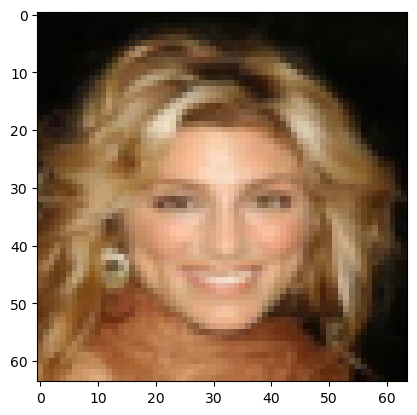

In [21]:
plt.imshow(source_image.permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')


In [22]:
torch.save(source_image.unsqueeze(0), "/home/luser/autoencoder_attacks/attack_examples/perturbation/celebA/bigVAE/images/sample23.pt")

In [1]:

Neighbourtrain_set, test_set = torch.utils.data.random_split(celeba_data, [int(len(img_list) * 1.0), len(img_list) - int(len(img_list) * 1.0)])


NeighbourhoodtrainLoader = torch.utils.data.DataLoader(Neighbourtrain_set,batch_size=batch_size, shuffle=False)
len(Neighbourtrain_set)

NameError: name 'torch' is not defined

###### How to calculate KL divergence when you have a multivariate Gaussian

KL_cur = 0.5 * torch.sum (((mu_so - mu_po)**2 / std_po**2) + (std_so**2 / std_po**2) - 1 - torch.log(std_so) + torch.log(std_po))


In [20]:
#recon_images, mu, logvar = model(source_image.unsqueeze(0).to(device))

#ae_perturbed_embeds = model_cnnvae_.encoder(adv_gen) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
nearest_original_neighbour0 = 0
nearest_original_neighbour1 = 0
nearest_original_neighbour2 = 0
nearest_original_neighbour3 = 0
nearest_original_neighbour4 = 0
nearest_original_neighbour5 = 0
nearest_original_neighbour6 = 0
nearest_original_neighbour7 = 0
nearest_original_neighbour8 = 0
all_neighbours = torch.tensor([]).to(device)


source_embeds = model.encoder(source_image.unsqueeze(0).to(device)) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
mu_so, logvar_so = model.fc1(source_embeds), model.fc2(source_embeds)
std_so = logvar_so.mul(0.5).exp_()
#esp_so = torch.randn(*mu_so.size()).to(device)
#z_so = mu_so + std_so * esp_so

#print("z_so.shape", z_so.shape)

pre_min_dist = 10**10
for idx, (image, label) in enumerate(NeighbourhoodtrainLoader):
    images, label = image.to(device), label.to(device)


    #for i in range(len(images)):
    #poten_neighbour = images[i]
    
    pot_neighbour_embeds = model.encoder(images.to(device)) # some confusion here. Why are you doin whatever you doing . Should not the input be  data + noise_outputs ?
    mu_po, logvar_po = model.fc1(pot_neighbour_embeds), model.fc2(pot_neighbour_embeds)
    std_po = logvar_po.mul(0.5).exp_()
    #esp_po = torch.randn(*mu_po.size()).to(device)
    #z_po = mu_po + std_po * esp_po

    #distances = torch.norm(z_po - z_so, dim=1)
    distances1 = torch.norm(mu_po - mu_so, dim=1)
    distances2 = torch.norm(std_po - std_so, dim=1)
    distances = distances1+distances2
    #distances = get_kl_divergences(mu_so, std_so, mu_po, std_po)
    #distances = 0.5 * torch.sum (((mu_so - mu_po)**2 / std_po**2) + (std_so**2 / std_po**2) - 1 - torch.log(std_so) + torch.log(std_po))
    #print("distances.shape", distances.shape)
    
    min_dist = distances.min()
    nearest_neighbor_index = torch.argmin(distances).item()
    #nearest_neighbor = z_po[nearest_neighbor_index]

    if (min_dist <= pre_min_dist): #use this in case you are using l2 distance 
    #if (min_dist <= pre_min_dist and min_dist> 32937.5945):# use this in case you are using KL divergence as a metric
        pre_min_dist = min_dist
        '''nearest_original_neighbour8 = nearest_original_neighbour7
        nearest_original_neighbour7 = nearest_original_neighbour6
        nearest_original_neighbour6 = nearest_original_neighbour5
        nearest_original_neighbour5 = nearest_original_neighbour4
        nearest_original_neighbour4 = nearest_original_neighbour3
        nearest_original_neighbour3 = nearest_original_neighbour2
        nearest_original_neighbour2 = nearest_original_neighbour1
        nearest_original_neighbour1 = nearest_original_neighbour0
        nearest_original_neighbour0 = images[nearest_neighbor_index]'''
        all_neighbours = torch.cat([all_neighbours, images[nearest_neighbor_index].unsqueeze(0)])
        print(all_neighbours.shape)
        all_neighbours = all_neighbours[-8:]
all_neighbours = torch.cat([all_neighbours, source_image.unsqueeze(0)])

#print("selected_neighbour.shape", nearest_original_neighbour0.shape)


torch.Size([1, 3, 64, 64])
torch.Size([2, 3, 64, 64])
torch.Size([3, 3, 64, 64])
torch.Size([4, 3, 64, 64])
torch.Size([5, 3, 64, 64])
torch.Size([6, 3, 64, 64])
torch.Size([7, 3, 64, 64])


KeyboardInterrupt: 

neighbours11 very good, neighbours12, neighbours13 very good, neighbours14 good

In [81]:
torch.save(all_neighbours, "/home/luser/autoencoder_attacks/train_aautoencoders/celeb_neighbours/neighbours14.pt")

In [82]:
test_ne = torch.load("/home/luser/autoencoder_attacks/train_aautoencoders/celeb_neighbours/neighbours14.pt")

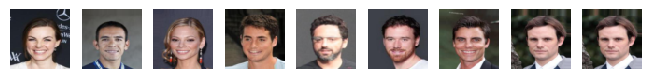

In [83]:
with torch.no_grad():
    fig = plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(1, 11,i+1)
        #plt.imshow(scale_noised_images[i][0].cpu().numpy())
        plt.imshow(test_ne[i].permute(1, 2, 0).cpu().detach().numpy(), cmap=plt.cm.gray_r, interpolation='nearest')

        plt.axis('off')
    plt.show()

In [77]:
def give_mean_sliced_wass_dist(allChImage1, allChImage2):
    mean_wass = 0
    for i in range(3):
        wassDistance = ot.sliced_wasserstein_distance(allChImage1[i], allChImage2[i], seed=0)  
        mean_wass = mean_wass + wassDistance
    return mean_wass/3